<a href="https://colab.research.google.com/github/numarahman/Loan-Approval-Prediction-Model/blob/main/Modeling_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Link of dataset (includes description of each column) : https://github.com/shrikant-temburwar/Loan-Prediction-Dataset/blob/master/README.md

In [ ]:
pip install ISLP

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 22.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 15.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 16.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.2/349.2 kB 9.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.0/522.0 kB 18.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.9/801.9 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 841.5/841.5 kB 15.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.2/94.2 kB 7.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pygam to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.2/522.2 kB 12.0 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7

In [ ]:
#importing packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         Stepwise,
                         sklearn_selected,
                         poly)
from ISLP import confusion_table
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import \
     (cross_validate)
from ISLP.models import sklearn_sm
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import scale


In [ ]:
#reading in csv files from github. the files were split up in training and testing sets, but I'll use train_test_split to split up my data
df1 = pd.read_csv('https://raw.githubusercontent.com/shrikant-temburwar/Loan-Prediction-Dataset/master/train.csv')
df2 = pd.read_csv('https://raw.githubusercontent.com/shrikant-temburwar/Loan-Prediction-Dataset/master/test.csv')

In [ ]:
#concatenating the two dataframes to have more entries
df = pd.concat([df1, df2])

In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
len(df)

981

# DATA CLEANING

In [ ]:
#seeing which columns have null values and how many they have
df.isnull().sum()

Loan_ID                0
Gender                24
Married                3
Dependents            25
Education              0
Self_Employed         55
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount            27
Loan_Amount_Term      20
Credit_History        79
Property_Area          0
Loan_Status          367
dtype: int64

In [ ]:
#datatypes of each column
#numerical values are needed in order to complete prediction tasks
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [ ]:
#drops all Nan values from dataframe
df = df.dropna()

## HOT ENCODING

In [ ]:
#variable encoding
yes_no_map = {'No': 0, 'Yes':1}
edu_map = {'Not Graduate': 0, 'Graduate':1}
gender_map = {'Male': 0, 'Female':1}
df['Education'] = df['Education'].apply(lambda x: edu_map[x])
df['Gender'] = df['Gender'].apply(lambda x: gender_map[x])
df['Married'] = df['Married'].apply(lambda x: yes_no_map[x])
df['Self_Employed'] = df['Self_Employed'].apply(lambda x: yes_no_map[x])
df['Dependents'] = df['Dependents'].apply(lambda x: int(x[0]))
#dummy variable encodiing
df = pd.get_dummies(df, columns = ['Property_Area'], dtype=float)

## PART OF DATA DICTIONARY

In [ ]:
#updated data dictionary that includes all column names and their datatypes
#description of each column is on the github page
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 480 entries, 1 to 613
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Loan_ID                  480 non-null    object 
 1   Gender                   480 non-null    int64  
 2   Married                  480 non-null    int64  
 3   Dependents               480 non-null    int64  
 4   Education                480 non-null    int64  
 5   Self_Employed            480 non-null    int64  
 6   ApplicantIncome          480 non-null    int64  
 7   CoapplicantIncome        480 non-null    float64
 8   LoanAmount               480 non-null    float64
 9   Loan_Amount_Term         480 non-null    float64
 10  Credit_History           480 non-null    float64
 11  Loan_Status              480 non-null    object 
 12  Property_Area_Rural      480 non-null    float64
 13  Property_Area_Semiurban  480 non-null    float64
 14  Property_Area_Urban      4

In [ ]:
#dropping Loan_ID because it is unimportant
df = df.drop('Loan_ID', axis = 1)

In [ ]:
df.head(10)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
1,0,1,1,1,0,4583,1508.0,128.0,360.0,1.0,N,1.0,0.0,0.0
2,0,1,0,1,1,3000,0.0,66.0,360.0,1.0,Y,0.0,0.0,1.0
3,0,1,0,0,0,2583,2358.0,120.0,360.0,1.0,Y,0.0,0.0,1.0
4,0,0,0,1,0,6000,0.0,141.0,360.0,1.0,Y,0.0,0.0,1.0
5,0,1,2,1,1,5417,4196.0,267.0,360.0,1.0,Y,0.0,0.0,1.0
6,0,1,0,0,0,2333,1516.0,95.0,360.0,1.0,Y,0.0,0.0,1.0
7,0,1,3,1,0,3036,2504.0,158.0,360.0,0.0,N,0.0,1.0,0.0
8,0,1,2,1,0,4006,1526.0,168.0,360.0,1.0,Y,0.0,0.0,1.0
9,0,1,1,1,0,12841,10968.0,349.0,360.0,1.0,N,0.0,1.0,0.0
10,0,1,2,1,0,3200,700.0,70.0,360.0,1.0,Y,0.0,0.0,1.0


## VISUALIZATIONS OF DATA

Text(0, 0.5, 'Count')

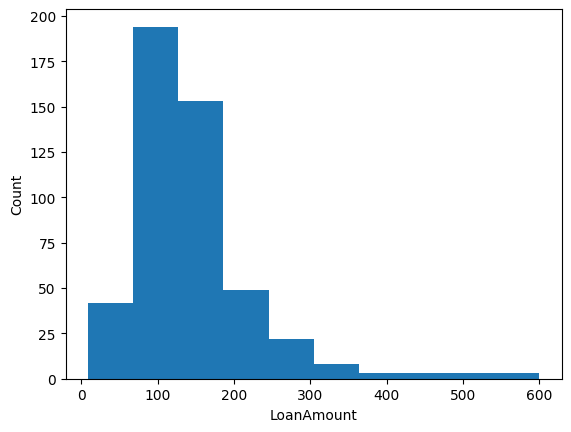

In [ ]:
#histogram of loan amount prior to model prediction
plt.hist(df['LoanAmount'], bins = 10)
plt.xlabel('LoanAmount')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

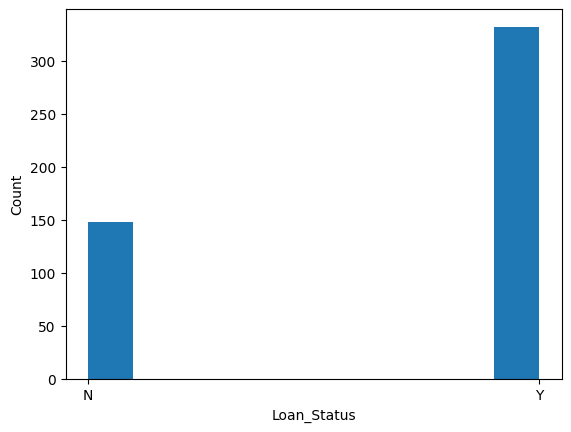

In [ ]:
#histogram of loan status prior to model prediction
plt.hist(df['Loan_Status'])
plt.xlabel('Loan_Status')
plt.ylabel('Count')

# QUALITATIVE PREDICTION USING LOGISTIC REGRESSION

In [ ]:
columns_to_scale = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[columns_to_scale] = scaler.fit_transform(df_scaled[columns_to_scale])

In [ ]:
df_scaled.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
1,0,1,1,1,0,-0.137970,-0.027952,-0.208089,0.275542,1.0,N,1.0,0.0,0.0
2,0,1,0,1,1,-0.417536,-0.604633,-0.979001,0.275542,1.0,Y,0.0,0.0,1.0
3,0,1,0,0,0,-0.491180,0.297100,-0.307562,0.275542,1.0,Y,0.0,0.0,1.0
4,0,0,0,1,0,0.112280,-0.604633,-0.046446,0.275542,1.0,Y,0.0,0.0,1.0
5,0,1,2,1,1,0.009319,0.999978,1.520245,0.275542,1.0,Y,0.0,0.0,1.0


In [ ]:
#setting X to be all variables except for the target
#setting Y equal to the target value Loan_Status
#predict that loan was approved
allvars = df_scaled.columns.drop(['Loan_Status'])
design = MS(allvars)
X = design.fit_transform(df_scaled)
y = df_scaled.Loan_Status == 'Y'

In [ ]:
y

1      False
2       True
3       True
4       True
5       True
       ...  
609     True
610     True
611     True
612     True
613    False
Name: Loan_Status, Length: 480, dtype: bool

In [ ]:
#splitting data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=42)
y_test

92      True
529     True
505     True
358    False
512     True
       ...  
58      True
20     False
577     True
476     True
4       True
Name: Loan_Status, Length: 144, dtype: bool

In [ ]:
#specifying logistic regression model
glm = sm.GLM(y_train,
             X_train,
             family=sm.families.Binomial())
#fitting the model
results = glm.fit()
#summarizing the results
summarize(results)

,coef,std err,z,P>|z|
intercept,-1.7208,0.425,-4.046,0.000
Gender,-0.5081,0.376,-1.353,0.176
Married,0.4710,0.343,1.375,0.169
Dependents,-0.0545,0.158,-0.345,0.730
Education,0.2393,0.372,0.644,0.520
Self_Employed,-0.1350,0.391,-0.345,0.730
ApplicantIncome,0.0917,0.162,0.566,0.572
CoapplicantIncome,-0.0830,0.165,-0.502,0.616
LoanAmount,-0.2684,0.174,-1.541,0.123
Loan_Amount_Term,-0.1209,0.162,-0.746,0.456


In [ ]:
#predicted probabilites of having loan approved
probs = results.predict(exog=X_test)
probs

92     0.788400
529    0.842077
505    0.723724
358    0.096496
512    0.789902
         ...   
58     0.792975
20     0.130215
577    0.743822
476    0.880353
4      0.749192
Length: 144, dtype: float64

In [ ]:
#converting predicted probabilities into labels based on threshold probability of .55
labels = np.zeros(len(probs))
labels[probs>.55] = 1
labels

array([1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.,
       0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1.,
       1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1.,
       1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 0., 1., 1., 1.])

In [ ]:
confusion_table(labels, y_test)

Truth,0.0,1.0
Predicted,,
0.0,16,0
1.0,28,100


In [ ]:
score = accuracy_score(labels,y_test)
print("Accuracy Score:", score)

Accuracy Score: 0.8055555555555556


## K-FOLD CROSS VALIDATION

In [ ]:
#3 k fold cross validation to compute test set score
length_model = sklearn_sm(sm.GLM,
                          MS(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
                              'ApplicantIncome','CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term',
                              'Credit_History', 'Property_Area_Rural', 'Property_Area_Semiurban', 'Property_Area_Urban']))
cv_results = cross_validate(length_model, X, y, cv = 3)
cv_results['test_score'].mean()

25.292443433140118

In [ ]:
cv_results

{'fit_time': array([0.06367421, 0.04246807, 0.03859282]),
 'score_time': array([0.01744199, 0.01891613, 0.0160296 ]),
 'test_score': array([28.5257278 , 23.8088923 , 23.54271021])}

## FEATURE SELECTION

In [ ]:
def negAIC(estimator, X, Y):
    "Negative AIC"
    n, p = X.shape
    Yhat = estimator.predict(X)
    MSE = np.mean((Y - Yhat)**2)
    return n + n * np.log(MSE) + 2 * (p + 1)

In [ ]:
strategy = Stepwise.first_peak(design, direction='forward', max_terms=len(design.terms))

In [ ]:
df_score = sklearn_selected(sm.GLM, strategy)
df_score.fit(df_scaled, y)
df_score.selected_state_

('ApplicantIncome',
 'CoapplicantIncome',
 'Credit_History',
 'Dependents',
 'Education',
 'Gender',
 'LoanAmount',
 'Loan_Amount_Term',
 'Married',
 'Property_Area_Rural',
 'Property_Area_Semiurban',
 'Self_Employed')

## ROC GRAPH

In [ ]:
#no skill model predicting all values belong in positive class (1)
ns_probs = np.ones(len(labels))
#auc score for no skill model
ns_auc = roc_auc_score(y_test, ns_probs)
print(ns_auc)

0.5


In [ ]:
#auc score for logistic model
lr_auc = roc_auc_score(y_test, labels)
print(lr_auc)

0.6818181818181819


In [ ]:
#false positive and true positive rates for no skill and logistic model
ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)
lr_fpr, lr_tpr, _ = roc_curve(y_test, probs)

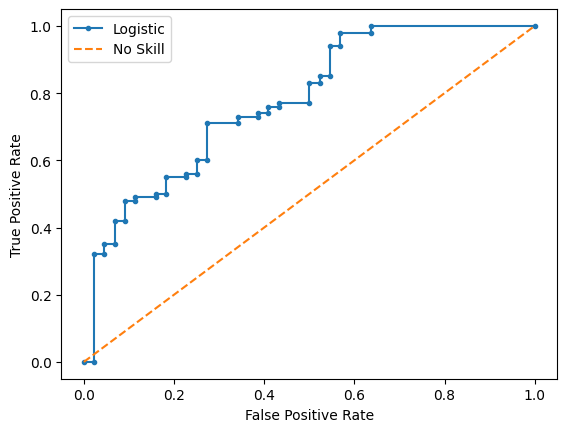

In [ ]:
plt.plot(lr_fpr, lr_tpr, marker='.', label='Logistic')
plt.plot(ns_fpr, ns_tpr, linestyle='--', label='No Skill')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

# QUANTITATIVE PREDICTION USING DECISION TREE REGRESSOR

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.tree import export_graphviz
from sklearn import tree
import pydotplus
import matplotlib.image as pltimg

In [ ]:
#filtering the dataframe to only include loans that were approved
df = df[df['Loan_Status'] == 'Y']

In [ ]:
#dropping target and loan status because it is not needed
x1 = df.drop(['LoanAmount', 'Loan_Status'], axis = 1)
y1 = df['LoanAmount']

Text(0, 0.5, 'Count')

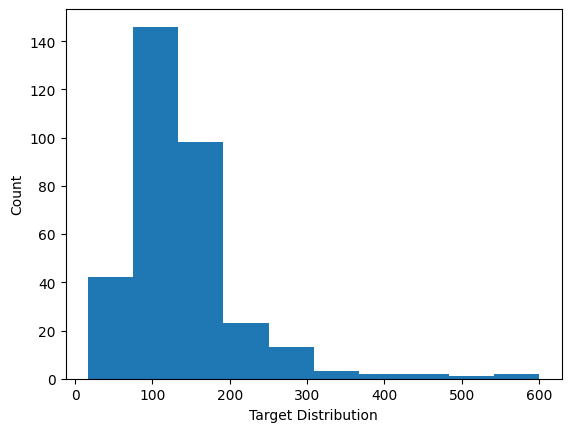

In [ ]:
#highlighting graphically the distribution of target values
plt.hist(y1)
plt.xlabel('Target Distribution')
plt.ylabel('Count')

In [ ]:
#splitting data into train and test sets
x_train1, x_test1, y_train1, y_test1 = train_test_split(x1, y1, test_size = 0.2, random_state = 28)

In [ ]:
#initializing the decision tree regressor model and fitting the model
modeling = DecisionTreeRegressor(random_state = 0, max_depth=3)
modeling.fit(x_train1, y_train1)

DecisionTreeRegressor(max_depth=3, random_state=0)

In [ ]:
#making a prediction
y_pred1 = modeling.predict(x_test1)

In [ ]:
#MSE score
rmse = float(format(np.sqrt(mean_squared_error(y_test1, y_pred1)), '.3f'))
print("\nRMSE: ", rmse)


RMSE:  98.143


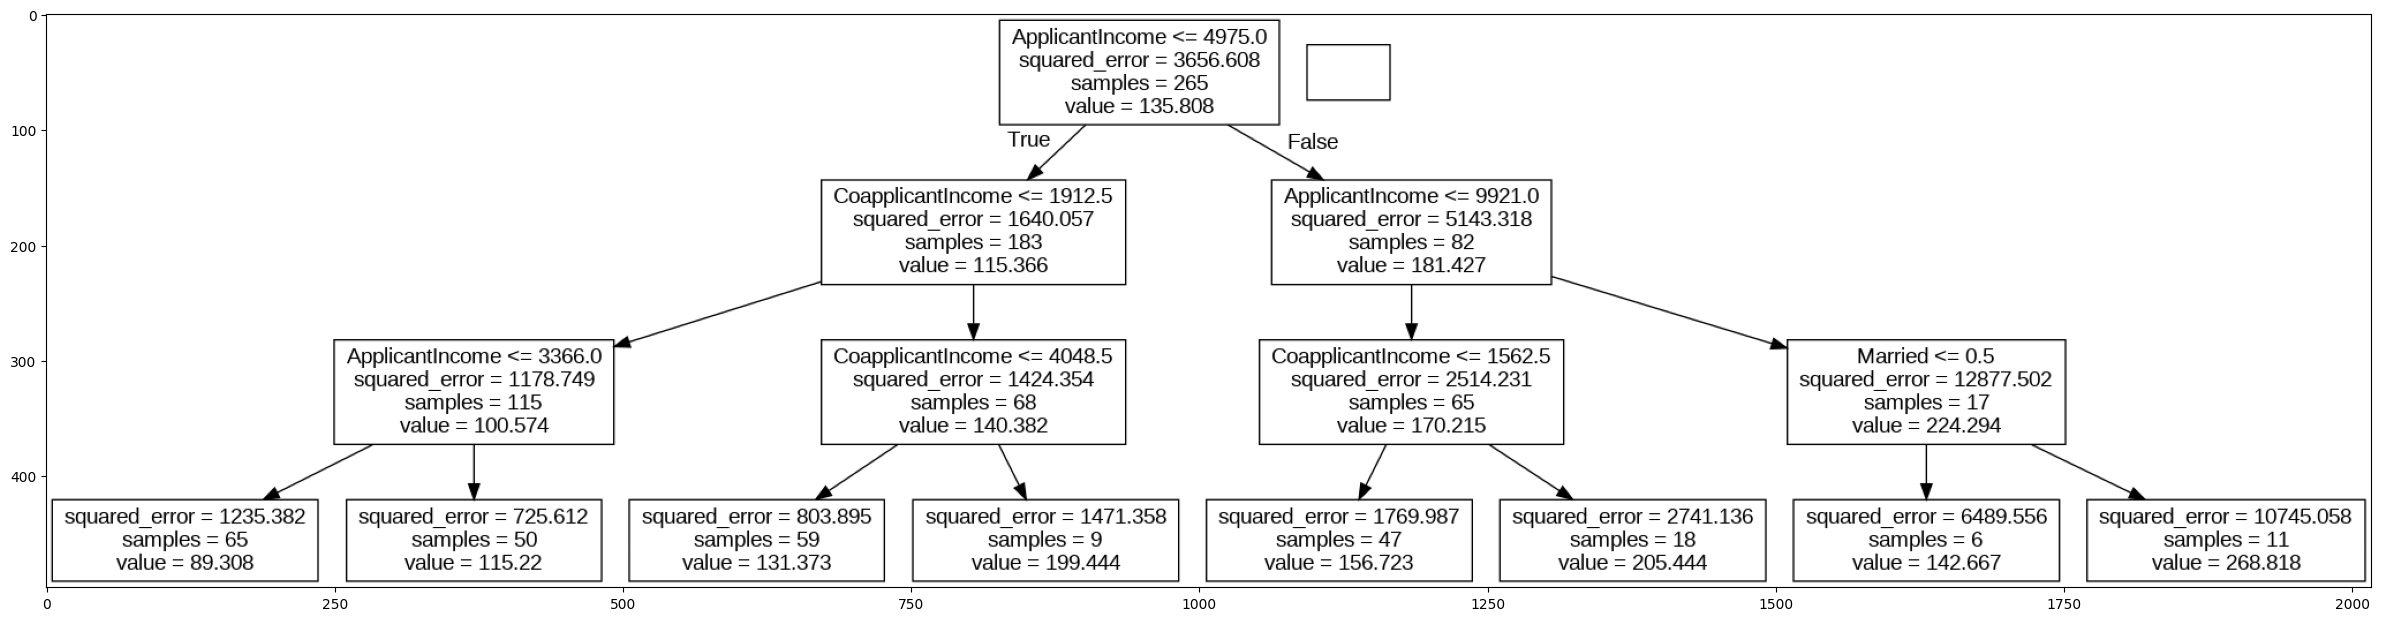

In [ ]:
#making a decision tree
feature_cols = x1.columns

plt_3 = plt.figure(figsize=(30, 30))
data = tree.export_graphviz(modeling, out_file=None, feature_names=feature_cols)
graph = pydotplus.graph_from_dot_data(data)
graph.write_png('mydecisiontree3.png')
img=pltimg.imread('mydecisiontree3.png')
imgplot = plt.imshow(img)
plt.show()

## Feature Importance

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'Gender'),
  Text(1, 0, 'Married'),
  Text(2, 0, 'Dependents'),
  Text(3, 0, 'Education'),
  Text(4, 0, 'Self_Employed'),
  Text(5, 0, 'ApplicantIncome'),
  Text(6, 0, 'CoapplicantIncome'),
  Text(7, 0, 'Loan_Amount_Term'),
  Text(8, 0, 'Credit_History'),
  Text(9, 0, 'Property_Area_Rural'),
  Text(10, 0, 'Property_Area_Semiurban'),
  Text(11, 0, 'Property_Area_Urban')])

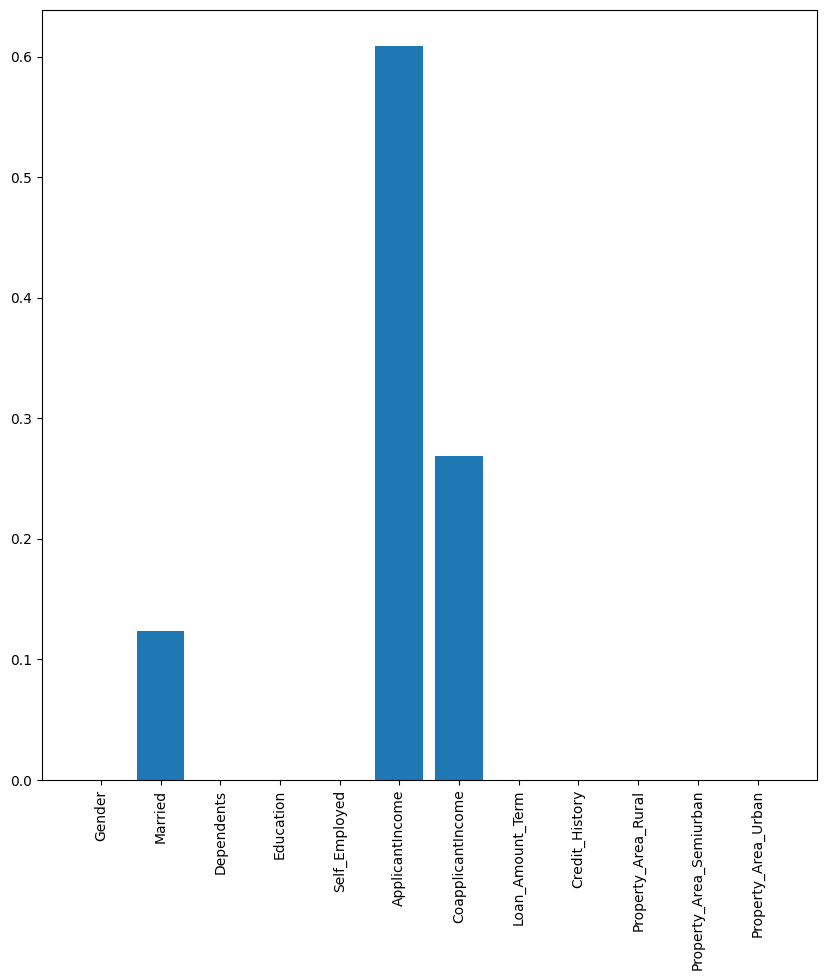

In [ ]:
#feature importance graph to select most important predictors
importances = modeling.feature_importances_
plt_2 = plt.figure(figsize=(10, 10))
plt.bar(feature_cols, importances)
plt.xticks(rotation = 'vertical')